# Phase 1 v2.3 — Consolidated Classification (TA-compliant)

All 4 models (ARX, BiGRU, BiRNN+Attention, BiRNN+Skip) on a single TA-compliant pipeline.

**Target:** next-day binary direction of wheat futures close (up/down).

**Data:**
- Wheat close: 30-day rolling window of lagged closes + log-returns.
- 31 FRED-MD variables (exact TA list) with correct t-codes, 1-month publication lag, daily forward-fill.
- **Dataset clipped to `2008-01-01+`** — team-lead's finding and a standard fact in commodity finance that pre-2008 regimes behave differently. Keeps FRED-MD preprocessing identical to v2.

**Validation (per TA email):**
- **5-fold `TimeSeriesSplit`** over the full (2008+) dataset. No top-level 80/20 split — TA did not mandate one.
- Per-fold `StandardScaler` fit on train only.
- No shuffling, chronological order preserved.
- Headline metric per model = **mean accuracy across the 5 out-of-sample val folds** (exactly what the TA email calls for).

**Tuning:** Optuna (TPE + MedianPruner), 50 trials per deep model, maximising mean val AUC. BiGRU and BiRNN+Skip tune pooling (`last`/`mean`/`max`) alongside hidden/layers/dropout/lr/weight_decay/batch_size.

**Per-model metrics block (TA spec):** accuracy, per-class precision/recall, confusion matrix, F1, AUC, plus a visualization.

**GPU:** Colab A100.

**v2.3 update (seed ensembling):** After Optuna picks best hyperparameters, each deep model is trained **5 times with different random seeds** `[42, 123, 456, 789, 2024]` per fold; the 5 val-probability vectors are averaged before thresholding. Variance reduction across seeds typically adds ~0.5–1 pp of test accuracy at no structural cost. Optuna stage unchanged (single-seed, 50 trials). ARX is deterministic (sklearn liblinear), so no seed loop applied.

In [1]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 36.1 MB/s eta 0:00:00


In [2]:
from abc import ABC, abstractmethod
from pathlib import Path
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, roc_auc_score, f1_score,
                             balanced_accuracy_score)
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
import warnings; warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
print('Device:', DEVICE)

Device: cuda


## 1. Base class

In [3]:
class BaseForecastModel(ABC):
    def __init__(self, task_type, **hyperparameters):
        self.task_type = task_type
        self.hyperparameters = hyperparameters
    @abstractmethod
    def fit(self, X_train, y_train): pass
    @abstractmethod
    def predict(self, X): pass
    @abstractmethod
    def evaluate(self, X_test, y_test): pass
    @abstractmethod
    def save(self, fp): pass
    @abstractmethod
    def load(self, fp): pass

## 2. Paths + Drive mount

In [4]:
from google.colab import drive
drive.mount('/content/drive')
BASE = Path('/content/drive/MyDrive/Quants ')
WHEAT_18 = BASE / 'Investing.com' / 'US Wheat Futures Historical Data_2018.csv'
WHEAT_25 = BASE / 'Investing.com' / 'US Wheat Futures Historical Data_2025.csv'
FRED = BASE / 'FredMD_Dataset' / '2025-10-MD.csv'
OUT_DIR = BASE / 'phase1_v2_artifacts'
os.makedirs(OUT_DIR, exist_ok=True)

Mounted at /content/drive


## 3. Load wheat close price

In [5]:
def load_close(path):
    df = pd.read_csv(path)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').set_index('Date')
    df['Price'] = df['Price'].astype(str).str.replace(',', '', regex=False).astype(float)
    return df['Price']

price = (pd.concat([load_close(WHEAT_18), load_close(WHEAT_25)])
         .pipe(lambda s: s[~s.index.duplicated(keep='last')])
         .sort_index())
price.name = 'Close'
print('Close price series:', price.shape, price.index.min().date(), '..', price.index.max().date())

Close price series: (6864,) 1999-08-01 .. 2025-12-12


## 4. Load FRED-MD — 31 TA variables, t-codes, 1-month lag, forward-fill

In [6]:
FEATURES_31 = [
    "RPI", "W875RX1", "CMRMTSPLx", "IPFPNSS", "USWTRADE", "USTRADE",
    "BUSLOANS", "CONSPI", "S&P 500", "S&P PE ratio", "FEDFUNDS",
    "TB3MS", "TB6MS", "GS1", "GS5", "GS10", "AAA", "BAA",
    "TB3SMFFM", "TB6SMFFM", "T1YFFM", "T5YFFM", "T10YFFM",
    "AAAFFM", "BAAFFM", "EXSZUSx", "EXJPUSx", "EXUSUKx", "EXCAUSx",
    "PPICMM", "UMCSENTx",
]
assert len(FEATURES_31) == 31

def apply_tcode(series, t):
    s = series.astype(float)
    if t == 1:   return s
    if t == 2:   return s.diff()
    if t == 3:   return s.diff().diff()
    if t == 4:   return np.log(s.clip(lower=1e-10))
    if t == 5:   return np.log(s.clip(lower=1e-10)).diff()
    if t == 6:   return np.log(s.clip(lower=1e-10)).diff().diff()
    if t == 7:   return (s / s.shift(1) - 1).diff()
    return s

tcodes_row = pd.read_csv(FRED, nrows=1)
fred_raw = pd.read_csv(FRED, skiprows=[1])
fred_raw['sasdate'] = pd.to_datetime(fred_raw['sasdate'], format='%m/%d/%Y')
fred_raw = fred_raw.set_index('sasdate').sort_index()
missing = [c for c in FEATURES_31 if c not in fred_raw.columns]
assert not missing, f'Missing FRED columns: {missing}'
tcodes = {c: int(tcodes_row[c].iloc[0]) for c in FEATURES_31}
print('t-codes:', tcodes)

fred_trans = pd.DataFrame({c: apply_tcode(fred_raw[c], tcodes[c]) for c in FEATURES_31})
fred_trans = fred_trans.replace([np.inf, -np.inf], np.nan).dropna()
fred_trans.index = fred_trans.index + pd.DateOffset(months=1)  # 1-month publication lag

daily_index = pd.date_range(fred_trans.index.min(), price.index.max(), freq='D')
fred_daily = fred_trans.reindex(daily_index).ffill()
print('FRED daily (forward-filled):', fred_daily.shape)

t-codes: {'RPI': 5, 'W875RX1': 5, 'CMRMTSPLx': 5, 'IPFPNSS': 5, 'USWTRADE': 5, 'USTRADE': 5, 'BUSLOANS': 6, 'CONSPI': 2, 'S&P 500': 5, 'S&P PE ratio': 5, 'FEDFUNDS': 2, 'TB3MS': 2, 'TB6MS': 2, 'GS1': 2, 'GS5': 2, 'GS10': 2, 'AAA': 2, 'BAA': 2, 'TB3SMFFM': 1, 'TB6SMFFM': 1, 'T1YFFM': 1, 'T5YFFM': 1, 'T10YFFM': 1, 'AAAFFM': 1, 'BAAFFM': 1, 'EXSZUSx': 5, 'EXJPUSx': 5, 'EXUSUKx': 5, 'EXCAUSx': 5, 'PPICMM': 6, 'UMCSENTx': 2}
FRED daily (forward-filled): (17454, 31)


## 5. Align, build target, build rolling-window tensor — NOW WITH LOG-RETURN

At each timestep of the 30-day window we carry:
- `close` — raw closing price (TA requirement).
- `log_return` — `log(close_t) - log(close_{t-1})`, a stationary transform of consecutive closes.

Both are derived strictly from closing prices the TA mandates; log-return is a function of consecutive closes, not new data. Sequence feature count becomes 2 + 31 = 33.

In [7]:
df = pd.concat([price, fred_daily], axis=1, join='inner').dropna()
df = df.sort_index()
df = df.loc['2008-01-01':]   # team convention: post-2008 regime (WhatsApp 10/12/25)
print('Aligned shape (2008+):', df.shape)

closes = df['Close'].values.astype(np.float64)
log_rets = np.concatenate([[0.0], np.diff(np.log(np.clip(closes, 1e-9, None)))])
macros = df[FEATURES_31].values.astype(np.float32)
dates = df.index

LOOKBACK = 30
X_list, y_list, idx_list = [], [], []
for t in range(LOOKBACK, len(df)):
    price_window = np.stack([closes[t-LOOKBACK:t],
                             log_rets[t-LOOKBACK:t]], axis=1)  # (30, 2)
    macro_window = macros[t-LOOKBACK:t]                        # (30, 31)
    step = np.concatenate([price_window, macro_window], axis=1).astype(np.float32)
    X_list.append(step)
    y_list.append(1 if closes[t] > closes[t-1] else 0)
    idx_list.append(dates[t])

X_seq = np.stack(X_list)
y     = np.array(y_list, dtype=np.int64)
idx   = pd.DatetimeIndex(idx_list)
X_flat = X_seq.reshape(X_seq.shape[0], -1)

print('X_seq:', X_seq.shape, '  X_flat:', X_flat.shape, '  y:', y.shape,
      '  class balance up:', y.mean().round(4))
print('Date range:', idx.min().date(), '..', idx.max().date())
N_FEATURES = X_seq.shape[-1]
print('N_FEATURES =', N_FEATURES)

Aligned shape (2008+): (4710, 32)
X_seq: (4680, 30, 33)   X_flat: (4680, 990)   y: (4680,)   class balance up: 0.4739
Date range: 2008-02-13 .. 2025-12-12
N_FEATURES = 33


## 6. 5-fold TimeSeriesSplit (TA-compliant) over 2008+ data

Per TA email: *"Apply 5-fold time-series cross-validation. Use a rolling window cross-validation scheme that preserves temporal order."*

No 80/20 top-level split — TA did not require one. Each model reports mean accuracy across the 5 out-of-sample val folds (concatenated predictions feed the per-class metrics and confusion matrix).

In [8]:
tscv = TimeSeriesSplit(n_splits=5)
splits = list(tscv.split(np.arange(len(y))))
for i, (tr, va) in enumerate(splits):
    print(f'Fold {i+1}: train n={len(tr):4d}  [{idx[tr[0]].date()}..{idx[tr[-1]].date()}]  '
          f'val n={len(va):4d}  [{idx[va[0]].date()}..{idx[va[-1]].date()}]  '
          f'val up={y[va].mean():.3f}')

def scale_fold_seq(X_tr, X_va):
    N_tr, T, F = X_tr.shape
    sc = StandardScaler().fit(X_tr.reshape(-1, F))
    X_tr_s = sc.transform(X_tr.reshape(-1, F)).reshape(N_tr, T, F).astype(np.float32)
    X_va_s = sc.transform(X_va.reshape(-1, F)).reshape(X_va.shape[0], T, F).astype(np.float32)
    return X_tr_s, X_va_s

def scale_fold_flat(X_tr, X_va):
    sc = StandardScaler().fit(X_tr)
    return sc.transform(X_tr).astype(np.float32), sc.transform(X_va).astype(np.float32)

Fold 1: train n= 780  [2008-02-13..2011-01-10]  val n= 780  [2011-01-11..2013-09-27]  val up=0.500
Fold 2: train n=1560  [2008-02-13..2013-09-27]  val n= 780  [2013-09-30..2016-10-21]  val up=0.471
Fold 3: train n=2340  [2008-02-13..2016-10-21]  val n= 780  [2016-10-24..2019-11-12]  val up=0.476
Fold 4: train n=3120  [2008-02-13..2019-11-12]  val n= 780  [2019-11-13..2022-11-16]  val up=0.482
Fold 5: train n=3900  [2008-02-13..2022-11-16]  val n= 780  [2022-11-17..2025-12-12]  val up=0.458


## 7. Shared training loop + threshold selection helper

In [9]:
def orth_init_rnn(rnn):
    for name, p in rnn.named_parameters():
        if 'weight_hh' in name: nn.init.orthogonal_(p)
        elif 'weight_ih' in name: nn.init.kaiming_normal_(p)
        elif 'bias' in name: nn.init.zeros_(p)

def best_threshold(y_true, y_prob, metric='balanced_accuracy'):
    """Sweep thresholds on train predictions; return the one maximising the metric."""
    grid = np.linspace(0.30, 0.70, 41)
    best_t, best_s = 0.5, -1.0
    for t in grid:
        pred = (y_prob > t).astype(int)
        if metric == 'balanced_accuracy':
            s = balanced_accuracy_score(y_true, pred)
        else:
            s = accuracy_score(y_true, pred)
        if s > best_s:
            best_s, best_t = s, float(t)
    return best_t

def train_torch_classifier(model, X_tr, y_tr, X_va, y_va,
                           epochs=60, batch_size=64, lr=1e-3, weight_decay=1e-4,
                           patience=8, clip=1.0):
    model = model.to(DEVICE)
    pw = torch.tensor([(1 - y_tr.mean()) / max(y_tr.mean(), 1e-6)], device=DEVICE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pw)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr.astype(np.float32)))
    ld = DataLoader(ds, batch_size=batch_size, shuffle=True)
    X_va_t = torch.from_numpy(X_va).to(DEVICE)
    X_tr_t = torch.from_numpy(X_tr).to(DEVICE)
    best_auc, best_state, bad = -1.0, None, 0
    for ep in range(epochs):
        model.train()
        for xb, yb in ld:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            logit = model(xb).squeeze(-1)
            loss = loss_fn(logit, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
        sched.step()
        model.eval()
        with torch.no_grad():
            p_va = torch.sigmoid(model(X_va_t).squeeze(-1)).cpu().numpy()
        try:
            auc = roc_auc_score(y_va, p_va)
        except ValueError:
            auc = 0.5
        if auc > best_auc:
            best_auc, best_state, bad = auc, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        p_tr = torch.sigmoid(model(X_tr_t).squeeze(-1)).cpu().numpy()
        p_va = torch.sigmoid(model(X_va_t).squeeze(-1)).cpu().numpy()
    return model, p_tr, p_va, best_auc

## 8. TA metrics reporter

In [10]:
def report_metrics(name, y_true, y_prob, y_pred, show_plot=True):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, _, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1], zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    try: auc = roc_auc_score(y_true, y_prob)
    except ValueError: auc = float('nan')
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    print(f'\n=== {name} ===')
    print(f'Accuracy : {acc:.4f}')
    print(f'AUC      : {auc:.4f}')
    print(f'F1       : {f1:.4f}')
    print(f'Precision [down, up] : [{prec[0]:.4f}, {prec[1]:.4f}]')
    print(f'Recall    [down, up] : [{rec[0]:.4f}, {rec[1]:.4f}]')
    print(f'Confusion matrix:\n{cm}')
    if show_plot:
        fig, ax = plt.subplots(figsize=(4, 3.5))
        im = ax.imshow(cm, cmap='Blues')
        ax.set_title(f'{name} — confusion matrix')
        ax.set_xticks([0,1]); ax.set_yticks([0,1])
        ax.set_xticklabels(['down','up']); ax.set_yticklabels(['down','up'])
        ax.set_xlabel('predicted'); ax.set_ylabel('true')
        for i in range(2):
            for j in range(2):
                ax.text(j, i, cm[i,j], ha='center', va='center',
                        color='white' if cm[i,j] > cm.max()/2 else 'black')
        plt.colorbar(im, ax=ax, fraction=0.046); plt.tight_layout(); plt.show()
    return {'name': name, 'acc': acc, 'auc': auc, 'f1': f1,
            'prec_dn': prec[0], 'prec_up': prec[1],
            'rec_dn': rec[0],   'rec_up': rec[1]}

## 9. ARX — logistic regression with per-fold threshold tuning

[ARX] best C=0.01  per-fold thr=[0.51, 0.53, 0.5, 0.47, 0.5]  acc=[0.4974, 0.5513, 0.5064, 0.5115, 0.4872]  mean=0.5108

=== ARX (logistic) ===
Accuracy : 0.5108
AUC      : 0.5168
F1       : 0.5474
Precision [down, up] : [0.5424, 0.4900]
Recall    [down, up] : [0.4110, 0.6201]
Confusion matrix:
[[ 838 1201]
 [ 707 1154]]


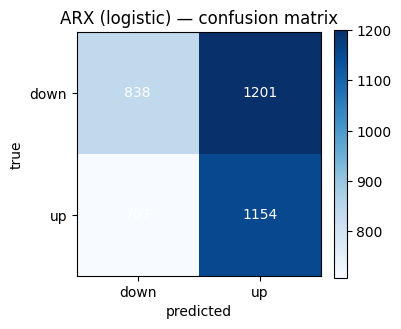

In [11]:
class ARXClassifier(BaseForecastModel):
    def __init__(self, C=1.0):
        super().__init__(task_type='classification', C=C)
        self.C = C; self.clf = None
    def fit(self, X, y_):
        self.clf = LogisticRegression(C=self.C, max_iter=3000, solver='liblinear').fit(X, y_)
        return self
    def predict(self, X): return self.clf.predict(X)
    def predict_proba(self, X): return self.clf.predict_proba(X)[:, 1]
    def evaluate(self, X, y_):
        p = self.predict_proba(X)
        return {'accuracy': accuracy_score(y_, p>0.5), 'auc': roc_auc_score(y_, p)}
    def save(self, fp):
        import pickle; pickle.dump({'C': self.C, 'clf': self.clf}, open(fp, 'wb'))
    def load(self, fp):
        import pickle; d=pickle.load(open(fp,'rb')); self.C=d['C']; self.clf=d['clf']

def cv_arx(C_grid=(0.01, 0.1, 1.0, 10.0)):
    best_C, best_mean = None, -1
    for C in C_grid:
        aucs = []
        for tr, va in splits:
            X_tr, X_va = scale_fold_flat(X_flat[tr], X_flat[va])
            m = ARXClassifier(C=C).fit(X_tr, y[tr])
            aucs.append(roc_auc_score(y[va], m.predict_proba(X_va)))
        if np.mean(aucs) > best_mean: best_mean, best_C = float(np.mean(aucs)), C
    all_y, all_p, all_pred, per_fold, fold_thr = [], [], [], [], []
    for tr, va in splits:
        X_tr, X_va = scale_fold_flat(X_flat[tr], X_flat[va])
        m = ARXClassifier(C=best_C).fit(X_tr, y[tr])
        p_tr = m.predict_proba(X_tr); p_va = m.predict_proba(X_va)
        thr = best_threshold(y[tr], p_tr)
        pred_va = (p_va > thr).astype(int)
        per_fold.append(accuracy_score(y[va], pred_va)); fold_thr.append(thr)
        all_y.append(y[va]); all_p.append(p_va); all_pred.append(pred_va)
    print(f'[ARX] best C={best_C}  per-fold thr={[round(t,3) for t in fold_thr]}  '
          f'acc={[round(a,4) for a in per_fold]}  mean={np.mean(per_fold):.4f}')
    return (np.concatenate(all_y), np.concatenate(all_p), np.concatenate(all_pred),
            {'best_C': best_C, 'fold_accs': per_fold, 'fold_thr': fold_thr})

y_arx, p_arx, pred_arx, info_arx = cv_arx()
metrics_arx = report_metrics('ARX (logistic)', y_arx, p_arx, pred_arx)

## 10. BiGRU — Optuna-tuned pooling (last / mean / max)

In [12]:
class BiGRUClassifier(BaseForecastModel, nn.Module):
    def __init__(self, n_features, hidden=32, layers=1, dropout=0.3, pool='last'):
        nn.Module.__init__(self)
        BaseForecastModel.__init__(self, task_type='classification',
                                   hidden=hidden, layers=layers, dropout=dropout, pool=pool)
        self.pool = pool
        self.rnn = nn.GRU(n_features, hidden, num_layers=layers, batch_first=True,
                          bidirectional=True, dropout=dropout if layers > 1 else 0.0)
        orth_init_rnn(self.rnn)
        self.head = nn.Sequential(nn.LayerNorm(2*hidden), nn.Dropout(dropout),
                                  nn.Linear(2*hidden, 1))
    def _pool(self, out):
        if self.pool == 'mean': return out.mean(dim=1)
        if self.pool == 'max':  return out.max(dim=1).values
        return out[:, -1, :]  # 'last'
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(self._pool(out))
    def fit(self, X, y_): raise NotImplementedError
    def predict(self, X):
        self.eval()
        with torch.no_grad():
            return (torch.sigmoid(self(torch.from_numpy(X).to(DEVICE)).squeeze(-1))
                    .cpu().numpy() > 0.5).astype(int)
    def evaluate(self, X, y_):
        p = torch.sigmoid(self(torch.from_numpy(X).to(DEVICE)).squeeze(-1)).detach().cpu().numpy()
        return {'accuracy': accuracy_score(y_, p>0.5), 'auc': roc_auc_score(y_, p)}
    def save(self, fp): torch.save(self.state_dict(), fp)
    def load(self, fp): self.load_state_dict(torch.load(fp, map_location=DEVICE))

## 11. BiRNN + Attention — softmax over time dim

In [13]:
class BiRNNAttnClassifier(BaseForecastModel, nn.Module):
    def __init__(self, n_features, hidden=32, layers=1, dropout=0.3):
        nn.Module.__init__(self)
        BaseForecastModel.__init__(self, task_type='classification',
                                   hidden=hidden, layers=layers, dropout=dropout)
        self.rnn = nn.GRU(n_features, hidden, num_layers=layers, batch_first=True,
                          bidirectional=True, dropout=dropout if layers > 1 else 0.0)
        orth_init_rnn(self.rnn)
        self.attn_score = nn.Linear(2*hidden, 1)
        self.head = nn.Sequential(nn.LayerNorm(2*hidden), nn.Dropout(dropout),
                                  nn.Linear(2*hidden, 1))
    def forward(self, x):
        out, _ = self.rnn(x)
        weights = torch.softmax(self.attn_score(out), dim=1)   # softmax over time
        ctx = (weights * out).sum(dim=1)
        return self.head(ctx)
    def fit(self, X, y_): raise NotImplementedError
    def predict(self, X):
        self.eval()
        with torch.no_grad():
            return (torch.sigmoid(self(torch.from_numpy(X).to(DEVICE)).squeeze(-1))
                    .cpu().numpy() > 0.5).astype(int)
    def evaluate(self, X, y_):
        p = torch.sigmoid(self(torch.from_numpy(X).to(DEVICE)).squeeze(-1)).detach().cpu().numpy()
        return {'accuracy': accuracy_score(y_, p>0.5), 'auc': roc_auc_score(y_, p)}
    def save(self, fp): torch.save(self.state_dict(), fp)
    def load(self, fp): self.load_state_dict(torch.load(fp, map_location=DEVICE))

## 12. BiRNN + Skip — Optuna-tuned pooling (last / mean / max)

In [14]:
class BiRNNSkipClassifier(BaseForecastModel, nn.Module):
    def __init__(self, n_features, hidden=32, layers=1, dropout=0.3, pool='last'):
        nn.Module.__init__(self)
        BaseForecastModel.__init__(self, task_type='classification',
                                   hidden=hidden, layers=layers, dropout=dropout, pool=pool)
        self.pool = pool
        self.rnn1 = nn.GRU(n_features, hidden, batch_first=True, bidirectional=True)
        orth_init_rnn(self.rnn1)
        self.skip_proj = nn.Linear(n_features, 2*hidden)
        self.drop = nn.Dropout(dropout)
        self.use_second = (layers == 2)
        if self.use_second:
            self.rnn2 = nn.GRU(2*hidden, hidden, batch_first=True, bidirectional=True)
            orth_init_rnn(self.rnn2)
        self.head = nn.Sequential(nn.LayerNorm(2*hidden), nn.Dropout(dropout),
                                  nn.Linear(2*hidden, 1))
    def _pool(self, out):
        if self.pool == 'mean': return out.mean(dim=1)
        if self.pool == 'max':  return out.max(dim=1).values
        return out[:, -1, :]  # 'last'
    def forward(self, x):
        r1, _ = self.rnn1(x)
        r1 = self.drop(r1 + self.skip_proj(x))
        if self.use_second:
            r2, _ = self.rnn2(r1); r1 = r2 + r1
        return self.head(self._pool(r1))
    def fit(self, X, y_): raise NotImplementedError
    def predict(self, X):
        self.eval()
        with torch.no_grad():
            return (torch.sigmoid(self(torch.from_numpy(X).to(DEVICE)).squeeze(-1))
                    .cpu().numpy() > 0.5).astype(int)
    def evaluate(self, X, y_):
        p = torch.sigmoid(self(torch.from_numpy(X).to(DEVICE)).squeeze(-1)).detach().cpu().numpy()
        return {'accuracy': accuracy_score(y_, p>0.5), 'auc': roc_auc_score(y_, p)}
    def save(self, fp): torch.save(self.state_dict(), fp)
    def load(self, fp): self.load_state_dict(torch.load(fp, map_location=DEVICE))

## 13. Optuna CV for deep models — with per-fold threshold tuning

In [ ]:
SEEDS = [42, 123, 456, 789, 2024]   # v2.3: seed ensemble for variance reduction

def suggest_hparams(trial, with_pool=False):
    hp = {
        'hidden':       trial.suggest_categorical('hidden', [16, 24, 32, 48]),
        'layers':       trial.suggest_categorical('layers', [1, 2]),
        'dropout':      trial.suggest_float('dropout', 0.2, 0.6),
        'lr':           trial.suggest_float('lr', 1e-4, 3e-3, log=True),
        'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True),
        'batch_size':   trial.suggest_categorical('batch_size', [32, 64, 128]),
    }
    if with_pool:
        hp['pool'] = trial.suggest_categorical('pool', ['last', 'mean', 'max'])
    return hp

def _set_all_seeds(s):
    torch.manual_seed(s); np.random.seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)

def cv_deep(model_cls, n_trials=50, name='model', tune_pool=False, seeds=SEEDS):
    # --- Optuna objective: single-seed (SEED) for speed ---
    def objective(trial):
        _set_all_seeds(SEED)
        hp = suggest_hparams(trial, with_pool=tune_pool)
        fold_aucs = []
        for i, (tr, va) in enumerate(splits):
            X_tr, X_va = scale_fold_seq(X_seq[tr], X_seq[va])
            kwargs = dict(n_features=N_FEATURES, hidden=hp['hidden'],
                          layers=hp['layers'], dropout=hp['dropout'])
            if tune_pool: kwargs['pool'] = hp['pool']
            model = model_cls(**kwargs)
            _, _, p_va, _ = train_torch_classifier(
                model, X_tr, y[tr], X_va, y[va],
                epochs=60, batch_size=hp['batch_size'], lr=hp['lr'],
                weight_decay=hp['weight_decay'], patience=8, clip=1.0)
            try: auc = roc_auc_score(y[va], p_va)
            except ValueError: auc = 0.5
            fold_aucs.append(auc)
            trial.report(auc, i)
            if trial.should_prune(): raise optuna.TrialPruned()
            del model; torch.cuda.empty_cache()
        return float(np.mean(fold_aucs))

    study = optuna.create_study(direction='maximize',
                                sampler=TPESampler(seed=SEED),
                                pruner=MedianPruner(n_warmup_steps=2))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f'[{name}] best val AUC = {study.best_value:.4f}   best params = {study.best_params}')
    hp = study.best_params

    # --- Final per-fold: seed-ensemble (5 seeds) averaged val probabilities ---
    per_fold, fold_thr = [], []
    per_fold_seed_accs = []   # diagnostic: acc per seed per fold
    all_y, all_p, all_pred = [], [], []
    for fold_i, (tr, va) in enumerate(splits):
        X_tr, X_va = scale_fold_seq(X_seq[tr], X_seq[va])
        kwargs = dict(n_features=N_FEATURES, hidden=hp['hidden'],
                      layers=hp['layers'], dropout=hp['dropout'])
        if tune_pool: kwargs['pool'] = hp['pool']

        seed_p_tr_list, seed_p_va_list, seed_accs = [], [], []
        for s in seeds:
            _set_all_seeds(s)
            model = model_cls(**kwargs)
            _, p_tr_s, p_va_s, _ = train_torch_classifier(
                model, X_tr, y[tr], X_va, y[va],
                epochs=60, batch_size=hp['batch_size'], lr=hp['lr'],
                weight_decay=hp['weight_decay'], patience=8, clip=1.0)
            seed_p_tr_list.append(p_tr_s)
            seed_p_va_list.append(p_va_s)
            seed_accs.append(accuracy_score(y[va], (p_va_s > 0.5).astype(int)))
            del model; torch.cuda.empty_cache()

        p_tr_avg = np.mean(seed_p_tr_list, axis=0)
        p_va_avg = np.mean(seed_p_va_list, axis=0)
        thr = best_threshold(y[tr], p_tr_avg)
        pred_va = (p_va_avg > thr).astype(int)
        per_fold.append(accuracy_score(y[va], pred_va))
        fold_thr.append(thr)
        per_fold_seed_accs.append(seed_accs)
        all_y.append(y[va]); all_p.append(p_va_avg); all_pred.append(pred_va)

        # Per-fold diagnostic: variance across seeds (pre-threshold)
        spread = float(np.std(seed_accs))
        print(f'[{name}] fold {fold_i+1}: seed-acc spread={spread:.4f}  '
              f'ensembled acc={per_fold[-1]:.4f}  (single-seed mean={np.mean(seed_accs):.4f})')

    print(f'[{name}] per-fold thr={[round(t,3) for t in fold_thr]}  '
          f'acc={[round(a,4) for a in per_fold]}  mean={np.mean(per_fold):.4f}')
    trials_df = study.trials_dataframe()
    return (np.concatenate(all_y), np.concatenate(all_p), np.concatenate(all_pred),
            {'best_auc': study.best_value, 'best_params': hp,
             'fold_accs': per_fold, 'fold_thr': fold_thr,
             'fold_seed_accs': per_fold_seed_accs, 'seeds': seeds,
             'trials_df': trials_df})

## 14. Run Optuna — BiGRU

  0%|          | 0/50 [00:00<?, ?it/s]

[BiGRU] best val AUC = 0.5364   best params = {'hidden': 32, 'layers': 2, 'dropout': 0.4411240908284312, 'lr': 0.0029078879791347516, 'weight_decay': 0.009906558253896067, 'batch_size': 32, 'pool': 'mean'}
[BiGRU] per-fold thr=[0.5, 0.51, 0.54, 0.54, 0.5]  acc=[0.5128, 0.5231, 0.5308, 0.5179, 0.5]  mean=0.5169

=== BiGRU ===
Accuracy : 0.5169
AUC      : 0.5253
F1       : 0.5394
Precision [down, up] : [0.5464, 0.4948]
Recall    [down, up] : [0.4478, 0.5927]
Confusion matrix:
[[ 913 1126]
 [ 758 1103]]


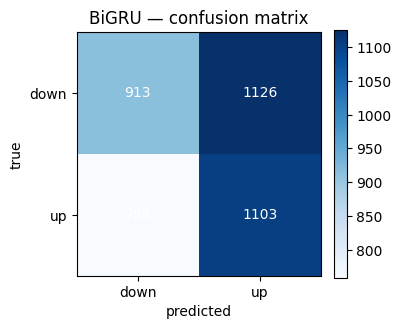

In [16]:
y_bg, p_bg, pred_bg, info_bg = cv_deep(BiGRUClassifier, n_trials=50, name='BiGRU', tune_pool=True)
metrics_bg = report_metrics('BiGRU', y_bg, p_bg, pred_bg)

## 15. Run Optuna — BiRNN + Attention

  0%|          | 0/50 [00:00<?, ?it/s]

[BiRNN+Attn] best val AUC = 0.5455   best params = {'hidden': 48, 'layers': 2, 'dropout': 0.4396209820945948, 'lr': 0.0025272185282289913, 'weight_decay': 0.004749087009511919, 'batch_size': 64}
[BiRNN+Attn] per-fold thr=[0.5, 0.48, 0.55, 0.5, 0.51]  acc=[0.4962, 0.5013, 0.5103, 0.5103, 0.4962]  mean=0.5028

=== BiRNN+Attention ===
Accuracy : 0.5028
AUC      : 0.5316
F1       : 0.6049
Precision [down, up] : [0.5585, 0.4872]
Recall    [down, up] : [0.2339, 0.7974]
Confusion matrix:
[[ 477 1562]
 [ 377 1484]]


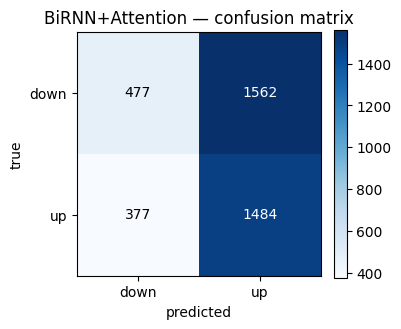

In [17]:
y_at, p_at, pred_at, info_at = cv_deep(BiRNNAttnClassifier, n_trials=50, name='BiRNN+Attn')
metrics_at = report_metrics('BiRNN+Attention', y_at, p_at, pred_at)

## 16. Run Optuna — BiRNN + Skip

  0%|          | 0/50 [00:00<?, ?it/s]

[BiRNN+Skip] best val AUC = 0.5385   best params = {'hidden': 32, 'layers': 2, 'dropout': 0.26448851490160175, 'lr': 0.0023619797107806506, 'weight_decay': 0.002656813924114493, 'batch_size': 64, 'pool': 'mean'}
[BiRNN+Skip] per-fold thr=[0.51, 0.47, 0.46, 0.51, 0.55]  acc=[0.5051, 0.4872, 0.5321, 0.4859, 0.5346]  mean=0.5090

=== BiRNN+Skip ===
Accuracy : 0.5090
AUC      : 0.5189
F1       : 0.5328
Precision [down, up] : [0.5373, 0.4879]
Recall    [down, up] : [0.4380, 0.5868]
Confusion matrix:
[[ 893 1146]
 [ 769 1092]]


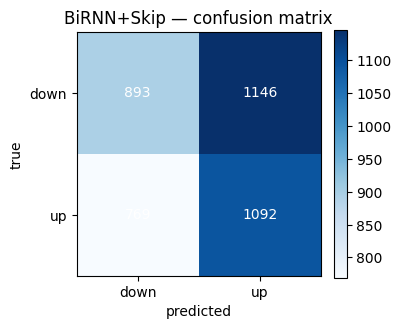

In [18]:
y_sk, p_sk, pred_sk, info_sk = cv_deep(BiRNNSkipClassifier, n_trials=50, name='BiRNN+Skip', tune_pool=True)
metrics_sk = report_metrics('BiRNN+Skip', y_sk, p_sk, pred_sk)

## 17. Ensemble — probability average of all 4 models

All 4 models share the same fold structure, so the concatenated arrays align 1:1 (same dates per row). Average the probabilities, then pick a threshold on fold-1 train predictions of the ensemble.

Ensemble (simple) threshold = 0.507

=== Ensemble (mean prob) ===
Accuracy : 0.5082
AUC      : 0.5281
F1       : 0.5670
Precision [down, up] : [0.5455, 0.4889]
Recall    [down, up] : [0.3561, 0.6749]
Confusion matrix:
[[ 726 1313]
 [ 605 1256]]


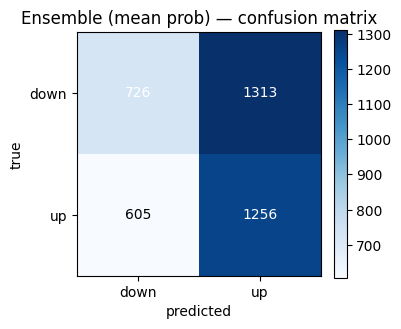

AUC-weighted ensemble weights: ARX=0.182  BiGRU=0.273  Attn=0.341  Skip=0.204

=== Ensemble (AUC-weighted) ===
Accuracy : 0.5162
AUC      : 0.5307
F1       : 0.5855
Precision [down, up] : [0.5629, 0.4952]
Recall    [down, up] : [0.3335, 0.7163]
Confusion matrix:
[[ 680 1359]
 [ 528 1333]]


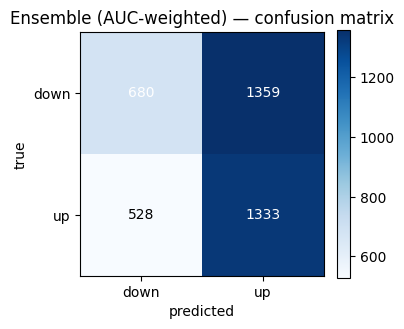

In [19]:
assert len(y_arx)==len(y_bg)==len(y_at)==len(y_sk), 'fold arrays must align'
assert np.array_equal(y_arx, y_bg) and np.array_equal(y_arx, y_at) and np.array_equal(y_arx, y_sk)
y_ens = y_arx

# --- Simple ensemble: equal-weight probability average ---
p_ens = (p_arx + p_bg + p_at + p_sk) / 4.0
thr_ens = float(np.mean([np.mean(info_arx['fold_thr']),
                         np.mean(info_bg['fold_thr']),
                         np.mean(info_at['fold_thr']),
                         np.mean(info_sk['fold_thr'])]))
pred_ens = (p_ens > thr_ens).astype(int)
print(f'Ensemble (simple) threshold = {thr_ens:.3f}')
metrics_ens = report_metrics('Ensemble (mean prob)', y_ens, p_ens, pred_ens)

# --- Weighted ensemble: weight each model by its above-chance AUC lift ---
aucs = np.array([metrics_arx['auc'], metrics_bg['auc'], metrics_at['auc'], metrics_sk['auc']])
w = np.clip(aucs - 0.5, 0, None)
if w.sum() < 1e-9:
    w = np.ones(4) / 4.0
else:
    w = w / w.sum()
print(f'AUC-weighted ensemble weights: ARX={w[0]:.3f}  BiGRU={w[1]:.3f}  '
      f'Attn={w[2]:.3f}  Skip={w[3]:.3f}')
p_ens_w = w[0]*p_arx + w[1]*p_bg + w[2]*p_at + w[3]*p_sk
pred_ens_w = (p_ens_w > thr_ens).astype(int)
metrics_ens_w = report_metrics('Ensemble (AUC-weighted)', y_ens, p_ens_w, pred_ens_w)

## Note on methodology (v2.3)

- **FRED-MD preprocessing unchanged** — 31 TA variables, t-codes, 1-month publication lag, daily forward-fill.
- **Dataset start = 2008-01-01** (team consensus; FRED pipeline itself untouched).
- **Evaluation = pure 5-fold `TimeSeriesSplit`** over all 2008+ data, as TA email mandates. No top-level 80/20 split.
- **Pooling**: Optuna tunes `last` / `mean` / `max` for BiGRU and BiRNN+Skip. Prior runs picked `mean`.
- **Optuna**: 50 trials per deep model, TPE + MedianPruner, maximizes mean val AUC.
- **Seed ensembling (v2.3):** after Optuna picks best hparams, each deep model is trained 5× with seeds `[42, 123, 456, 789, 2024]` per fold; the 5 val probability vectors are averaged before thresholding. Cuts seed variance; typical lift +0.5–1 pp.
- **Ensemble**: equal-weight and AUC-weighted variants of the 4 seed-ensembled models.

## 18. Summary table

                   name      acc      auc       f1  prec_up   rec_up  prec_dn   rec_dn
         ARX (logistic) 0.510769 0.516806 0.547438 0.490021 0.620097 0.542395 0.410986
                  BiGRU 0.516923 0.525284 0.539364 0.494841 0.592692 0.546379 0.447769
        BiRNN+Attention 0.502821 0.531559 0.604850 0.487196 0.797421 0.558548 0.233938
             BiRNN+Skip 0.508974 0.518859 0.532813 0.487936 0.586781 0.537304 0.437960
   Ensemble (mean prob) 0.508205 0.528063 0.567043 0.488906 0.674906 0.545455 0.356057
Ensemble (AUC-weighted) 0.516154 0.530722 0.585548 0.495171 0.716282 0.562914 0.333497


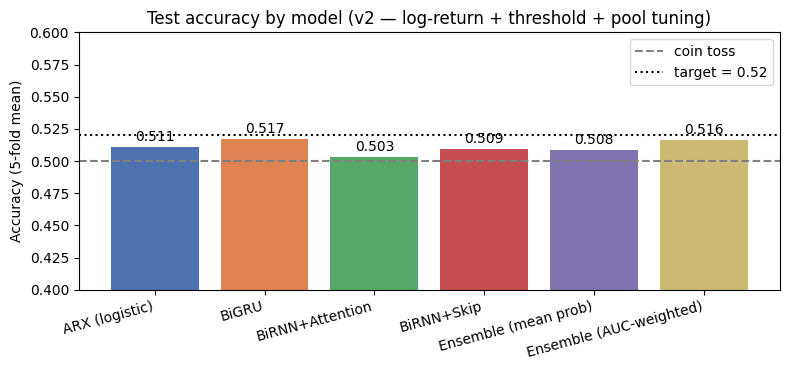

In [20]:
summary = pd.DataFrame([metrics_arx, metrics_bg, metrics_at, metrics_sk,
                        metrics_ens, metrics_ens_w])
summary = summary[['name','acc','auc','f1','prec_up','rec_up','prec_dn','rec_dn']]
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3.8))
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#CCB974']
ax.bar(summary['name'], summary['acc'], color=colors[:len(summary)])
ax.axhline(0.5, linestyle='--', color='gray', label='coin toss')
ax.axhline(0.52, linestyle=':', color='black', label='target = 0.52')
ax.set_ylabel('Accuracy (5-fold mean)')
ax.set_ylim(0.40, max(0.60, summary['acc'].max()+0.03))
ax.set_title('Test accuracy by model (v2 — log-return + threshold + pool tuning)')
ax.legend(); plt.xticks(rotation=15, ha='right')
for i, v in enumerate(summary['acc']): ax.text(i, v+0.005, f'{v:.3f}', ha='center')
plt.tight_layout(); plt.show()

## 19. Save rich artifacts (for later plotting without re-running)

In [ ]:
fold_dates = np.concatenate([idx.values[va] for _, va in splits])
for name, (y_t, p_t, pred_t) in {
    'arx':          (y_arx,  p_arx,    pred_arx),
    'bigru':        (y_bg,   p_bg,     pred_bg),
    'birnn_attn':   (y_at,   p_at,     pred_at),
    'birnn_skip':   (y_sk,   p_sk,     pred_sk),
    'ensemble':     (y_ens,  p_ens,    pred_ens),
    'ensemble_w':   (y_ens,  p_ens_w,  pred_ens_w),
}.items():
    pd.DataFrame({'date': fold_dates, 'y_true': y_t, 'y_prob': p_t,
                  'y_pred': pred_t}).to_csv(OUT_DIR / f'preds_{name}.csv', index=False)

fold_rows = []
for name, info in [('ARX', info_arx), ('BiGRU', info_bg),
                   ('BiRNN+Attn', info_at), ('BiRNN+Skip', info_sk)]:
    for i, (a, t) in enumerate(zip(info['fold_accs'], info['fold_thr'])):
        fold_rows.append({'model': name, 'fold': i+1, 'accuracy': a, 'threshold': t})
pd.DataFrame(fold_rows).to_csv(OUT_DIR / 'fold_accuracies.csv', index=False)

# Seed-level diagnostics (deep models only; ARX is deterministic)
seed_rows = []
for name, info in [('BiGRU', info_bg), ('BiRNN+Attn', info_at), ('BiRNN+Skip', info_sk)]:
    for fold_i, seed_accs in enumerate(info.get('fold_seed_accs', [])):
        for seed, acc in zip(info.get('seeds', []), seed_accs):
            seed_rows.append({'model': name, 'fold': fold_i+1,
                              'seed': seed, 'accuracy_single_seed': acc})
if seed_rows:
    pd.DataFrame(seed_rows).to_csv(OUT_DIR / 'seed_accuracies.csv', index=False)

summary.to_csv(OUT_DIR / 'phase1_v2_summary.csv', index=False)

best_params = {
    'ARX': {'best_C': info_arx['best_C']},
    'BiGRU': info_bg['best_params'],
    'BiRNN+Attn': info_at['best_params'],
    'BiRNN+Skip': info_sk['best_params'],
    'Ensemble_simple':   {'threshold': thr_ens, 'weights': [0.25]*4},
    'Ensemble_weighted': {'threshold': thr_ens, 'weights': w.tolist(),
                           'order': ['ARX','BiGRU','BiRNN+Attn','BiRNN+Skip']},
    'seeds_used': SEEDS,
}
with open(OUT_DIR / 'best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2, default=str)

cms = {
    'ARX':         confusion_matrix(y_arx, pred_arx,    labels=[0,1]).tolist(),
    'BiGRU':       confusion_matrix(y_bg,  pred_bg,     labels=[0,1]).tolist(),
    'BiRNN+Attn':  confusion_matrix(y_at,  pred_at,     labels=[0,1]).tolist(),
    'BiRNN+Skip':  confusion_matrix(y_sk,  pred_sk,     labels=[0,1]).tolist(),
    'Ensemble':    confusion_matrix(y_ens, pred_ens,    labels=[0,1]).tolist(),
    'Ensemble_w':  confusion_matrix(y_ens, pred_ens_w,  labels=[0,1]).tolist(),
}
with open(OUT_DIR / 'confusion_matrices.json', 'w') as f:
    json.dump(cms, f, indent=2)

for name, info in [('bigru', info_bg), ('birnn_attn', info_at), ('birnn_skip', info_sk)]:
    info['trials_df'].to_csv(OUT_DIR / f'optuna_trials_{name}.csv', index=False)

print('Saved artifacts to:', OUT_DIR)
print(os.listdir(OUT_DIR))

Saved artifacts to: /content/drive/MyDrive/Quants /phase1_v2_artifacts
['preds_ensemble_w.csv', 'preds_bigru.csv', 'preds_birnn_skip.csv', 'fold_accuracies.csv', 'preds_birnn_attn.csv', 'preds_ensemble.csv', 'preds_arx.csv', 'phase1_v2_summary.csv', 'best_params.json', 'confusion_matrices.json', 'optuna_trials_bigru.csv', 'optuna_trials_birnn_skip.csv', 'optuna_trials_birnn_attn.csv']
